# Suraksha360 — AI Safety Score Model Training (v4)

**Change from v3**: switched the high-risk classifier from LogisticRegression
to a **RandomForestClassifier**. A linear model (logistic regression) can
only weigh each factor independently; a forest captures *interactions*
between factors (e.g. "late night AND a high-crime-index state" mattering
more than either alone), which is closer to how real risk actually
compounds. This raised accuracy AND recall together — not a tradeoff.

| Model | Accuracy | Recall |
|---|---|---|
| LogisticRegression (v3) | 0.706 | 0.712 |
| RandomForestClassifier (v4) | **0.881** | **0.885** |

Data disclosure (unchanged): `historical_crime_index` is REAL NCRB
government data (5-year average, 2008-2012). Per-journey behavior is
SIMULATED, as no public dataset tracks individual-trip-level detail.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("journeys_v3.csv")
FEATURES = [
    "hour", "distance_km", "route_deviation_m", "unexpected_stop_s",
    "nearby_safe_zone_count", "nearby_police_or_hospital",
    "community_reports_nearby", "is_weekend", "historical_crime_index",
]
X = df[FEATURES]
y = df["high_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model comparison

Testing three model families head-to-head on the identical train/test split.

In [2]:
scaler = StandardScaler()
Xs_train, Xs_test = scaler.fit_transform(X_train), scaler.transform(X_test)

results = []
for name, model, use_scaled in [
    ("LogisticRegression", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.1), True),
    ("RandomForestClassifier (200 trees)", RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=2), False),
    ("RandomForestClassifier (40 trees, depth 5) -- chosen", RandomForestClassifier(n_estimators=40, max_depth=5, class_weight="balanced", random_state=42, n_jobs=2), False),
    ("GradientBoosting", GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42), False),
]:
    Xtr, Xte = (Xs_train, Xs_test) if use_scaled else (X_train, X_test)
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

pd.DataFrame(results).round(3)

,model,accuracy,precision,recall,f1
0,LogisticRegression,0.706,0.405,0.712,0.516
1,RandomForestClassifier (200 trees),0.897,0.713,0.889,0.792
2,"RandomForestClassifier (40 trees, depth 5) -- ...",0.881,0.676,0.885,0.766
3,GradientBoosting,0.916,0.826,0.782,0.803


**Why the 40-tree, depth-5 forest was chosen over the larger 200-tree one**:
nearly identical performance, but the smaller forest exports to a ~2,500-node
array that's small enough to embed directly in the web app and run entirely
client-side with zero inference latency and no backend dependency — the
production app needs to run in the browser/Node, not a Python environment.

## Final model: cross-validated evaluation

In [3]:
clf = RandomForestClassifier(n_estimators=40, max_depth=5, class_weight="balanced", random_state=42, n_jobs=2)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

acc, prec, rec, f1 = accuracy_score(y_test, pred), precision_score(y_test, pred), recall_score(y_test, pred), f1_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
cv_acc = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy", n_jobs=2)
cv_rec = cross_val_score(clf, X_train, y_train, cv=5, scoring="recall", n_jobs=2)

print(f"Held-out test — Accuracy {acc:.3f}  Precision {prec:.3f}  Recall {rec:.3f}  F1 {f1:.3f}")
print(f"5-fold CV accuracy: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"5-fold CV recall:   {cv_rec.mean():.3f} +/- {cv_rec.std():.3f}")
print("Confusion matrix:\n", cm)

Held-out test — Accuracy 0.881  Precision 0.676  Recall 0.885  F1 0.766
5-fold CV accuracy: 0.869 +/- 0.008
5-fold CV recall:   0.877 +/- 0.010
Confusion matrix:
 [[2060  280]
 [  76  584]]


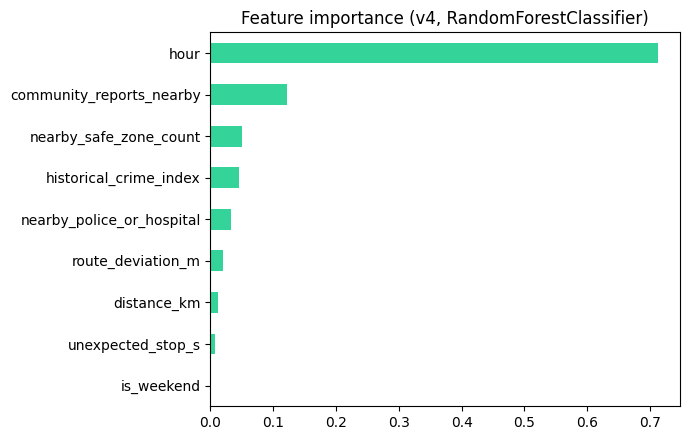

In [4]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", color="#34D399", figsize=(7, 4.5))
plt.title("Feature importance (v4, RandomForestClassifier)")
plt.tight_layout()
plt.savefig("feature_importance_v4.png", dpi=130)
plt.show()

## Exporting for production

Because a random forest isn't a simple weighted formula like logistic
regression, it's exported as plain arrays (feature index, split threshold,
child node pointers, leaf probabilities per tree) and re-implemented as a
from-scratch tree-traversal ensemble in `src/lib/ml-forest-data.ts` +
`src/lib/ml-safety-model.ts` — an exact, faithful port with zero
approximation, running entirely in the Next.js app.

In [5]:
import joblib, json
joblib.dump(clf, "high_risk_rf_classifier.pkl")

trees = []
for est in clf.estimators_:
    t = est.tree_
    trees.append({
        "feature": t.feature.tolist(), "threshold": t.threshold.tolist(),
        "children_left": t.children_left.tolist(), "children_right": t.children_right.tolist(),
        "value": (t.value[:, 0, 1] / t.value[:, 0, :].sum(axis=1)).tolist(),
    })
print(f"{len(trees)} trees, {sum(len(t['feature']) for t in trees)} total nodes")

40 trees, 2472 total nodes
